In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

from utils import parse_latencies_trt, parse_power_log, get_power_index, compute_layer_metrics_by_cycle

In [2]:
DATA_PATH = Path('../raw_data/single_conv_layer_trt')

In [3]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 3576245.017657479


## Single Convolution Layers


### Kernel 1 Stride 1 Output 3

In [4]:
model_name = 'conv_k1_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 34.45it/s]


In [5]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o3: 17278
Number of TensorRT layers in conv_k1_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.771303 seconds


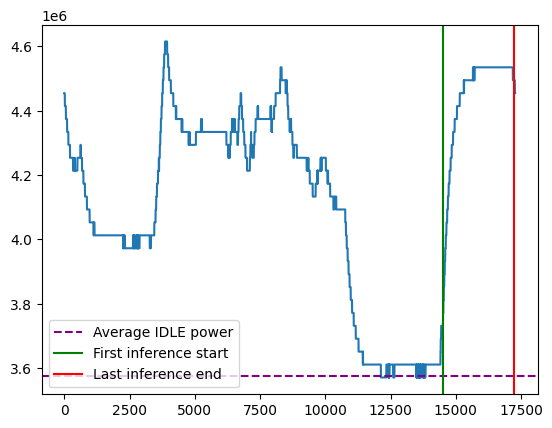

In [6]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [7]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k1 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 390955.79it/s]


In [8]:
metrics_df_k1.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,5.880000e+02,588.000000,3000.000000
mean,1500.500000,4.461032e+06,884787.472138,0.273359
std,866.169729,1.485564e+05,148556.378890,0.053302
min,1.000000,3.731904e+06,155658.982343,0.251808
25%,750.750000,4.494336e+06,918090.982343,0.274720
50%,1500.500000,4.534464e+06,958218.982343,0.275648
75%,2250.250000,4.534464e+06,958218.982343,0.276352
max,3000.000000,4.534464e+06,958218.982343,2.946720


In [9]:
metrics_df_k1.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     588
layer_power_excluding_idle_power_micro_watt     588
layer_run_time                                 3000
dtype: int64

<Axes: >

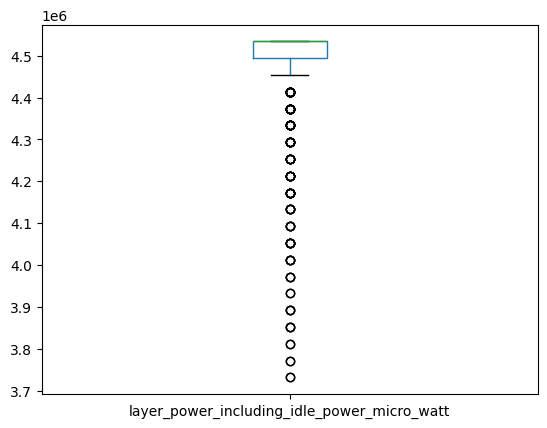

In [10]:
metrics_df_k1.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 2 Stride 2 Output 3

In [11]:
model_name = 'conv_k1_s2_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 34.75it/s]


In [12]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s2_o3: 14211
Number of TensorRT layers in conv_k1_s2_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.323481 seconds


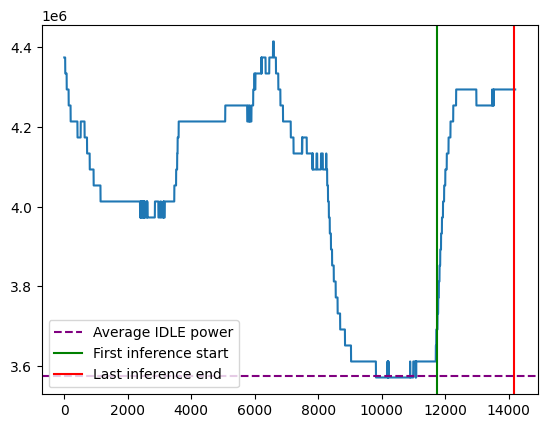

In [13]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [14]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k2 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 757413.59it/s]


In [15]:
metrics_df_k2.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,2.170000e+02,217.000000,3000.000000
mean,1500.500000,4.251904e+06,675658.687412,0.101408
std,866.169729,1.013781e+05,101378.062362,0.010474
min,1.000000,3.731904e+06,155658.982343,0.081728
25%,750.750000,4.253568e+06,677322.982343,0.103872
50%,1500.500000,4.293696e+06,717450.982343,0.104992
75%,2250.250000,4.293696e+06,717450.982343,0.105728
max,3000.000000,4.293696e+06,717450.982343,0.189664


In [16]:
metrics_df_k2.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     217
layer_power_excluding_idle_power_micro_watt     217
layer_run_time                                 3000
dtype: int64

<Axes: >

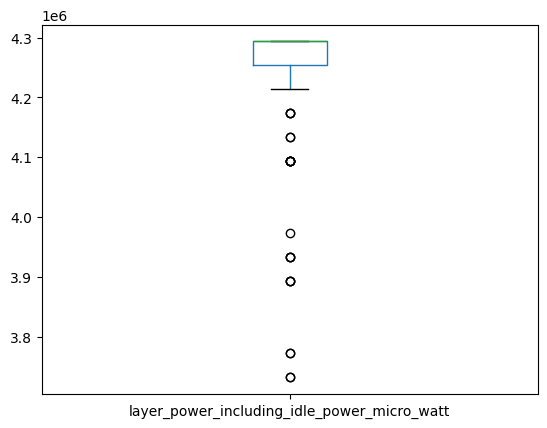

In [17]:
metrics_df_k2.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 3 Stride 3 Output 3

In [18]:
model_name = 'conv_k1_s3_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 21.27it/s]


In [19]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s3_o3: 14428
Number of TensorRT layers in conv_k1_s3_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.015882 seconds


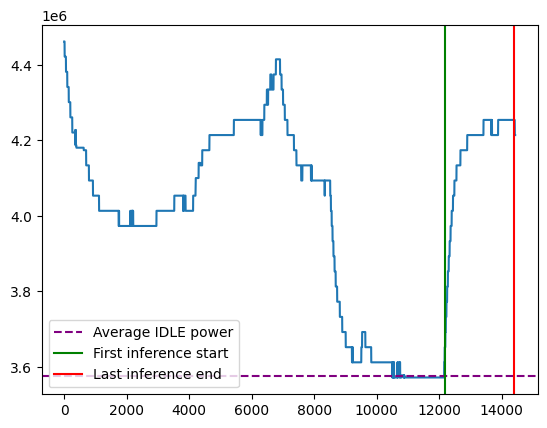

In [20]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [21]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k3 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 962217.02it/s]


In [22]:
metrics_df_k3.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,1.580000e+02,158.000000,3000.000000
mean,1500.500000,4.199471e+06,623226.374748,0.070076
std,866.169729,8.675663e+04,86756.625013,0.007171
min,1.000000,3.812160e+06,235914.982343,0.048736
25%,750.750000,4.173312e+06,597066.982343,0.071392
50%,1500.500000,4.213440e+06,637194.982343,0.072032
75%,2250.250000,4.253568e+06,677322.982343,0.072640
max,3000.000000,4.253568e+06,677322.982343,0.112992


In [23]:
metrics_df_k3.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     158
layer_power_excluding_idle_power_micro_watt     158
layer_run_time                                 3000
dtype: int64

<Axes: >

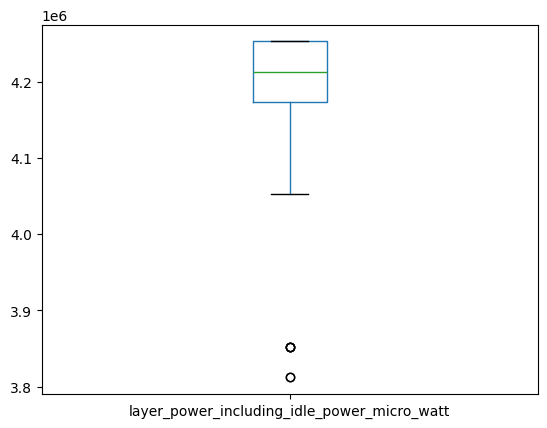

In [24]:
metrics_df_k3.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 1 Stride 4 Output 3

In [25]:
model_name = 'conv_k1_s4_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 34.69it/s]


In [26]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s4_o3: 14186
Number of TensorRT layers in conv_k1_s4_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 2.9634 seconds


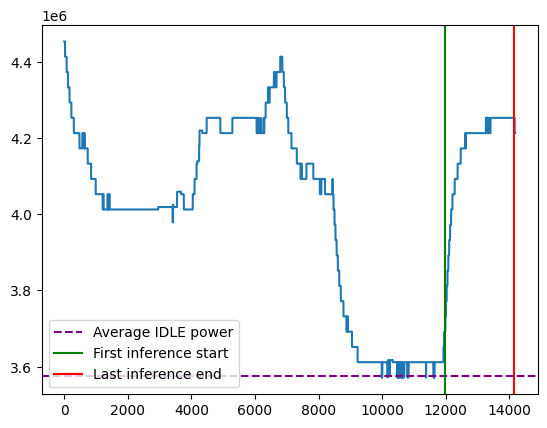

In [27]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[len(latency_data)-1][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [28]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k4 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 575824.27it/s]


In [29]:
metrics_df_k4.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,1.260000e+02,126.000000,3000.000000
mean,1500.500000,4.196879e+06,620634.220438,0.060258
std,866.169729,9.168451e+04,91684.510780,0.006269
min,1.000000,3.691776e+06,115530.982343,0.038976
25%,750.750000,4.183344e+06,607098.982343,0.061088
50%,1500.500000,4.213440e+06,637194.982343,0.061664
75%,2250.250000,4.253568e+06,677322.982343,0.062240
max,3000.000000,4.253568e+06,677322.982343,0.097952


In [30]:
metrics_df_k4.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     126
layer_power_excluding_idle_power_micro_watt     126
layer_run_time                                 3000
dtype: int64

<Axes: >

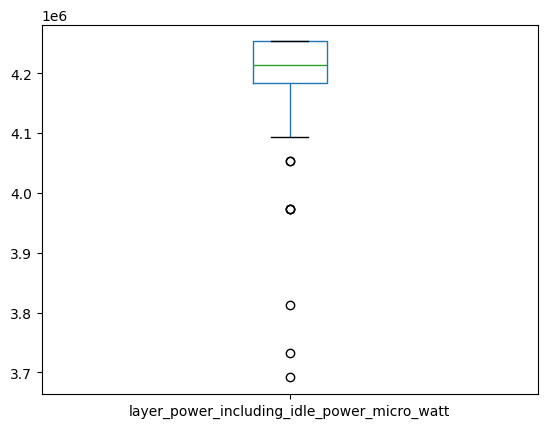

In [31]:
metrics_df_k4.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 1 Stride 5 Output 3

In [32]:
model_name = 'conv_k1_s5_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 22.10it/s]


In [33]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s5_o3: 14242
Number of TensorRT layers in conv_k1_s5_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 2.973237 seconds


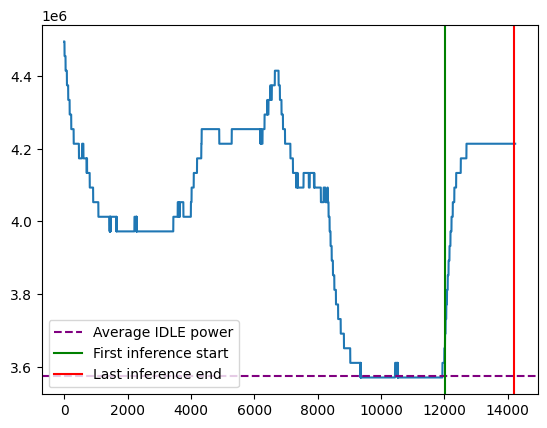

In [34]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [35]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k5 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 437225.48it/s]


In [36]:
metrics_df_k5.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,1.260000e+02,126.000000,3000.000000
mean,1500.500000,4.178089e+06,601844.125200,0.053114
std,866.169729,9.941476e+04,99414.755503,0.007228
min,1.000000,3.731904e+06,155658.982343,0.033376
25%,750.750000,4.213440e+06,637194.982343,0.054496
50%,1500.500000,4.213440e+06,637194.982343,0.055168
75%,2250.250000,4.213440e+06,637194.982343,0.055776
max,3000.000000,4.213440e+06,637194.982343,0.094624


In [37]:
metrics_df_k5.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     126
layer_power_excluding_idle_power_micro_watt     126
layer_run_time                                 3000
dtype: int64

<Axes: >

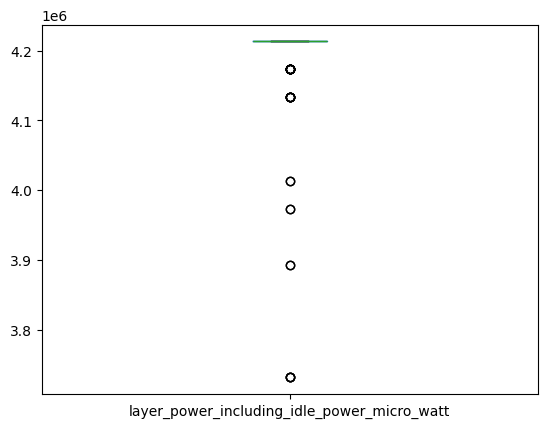

In [38]:
metrics_df_k5.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

## Strides Plot

Text(0.5, 0, 'Stride size')

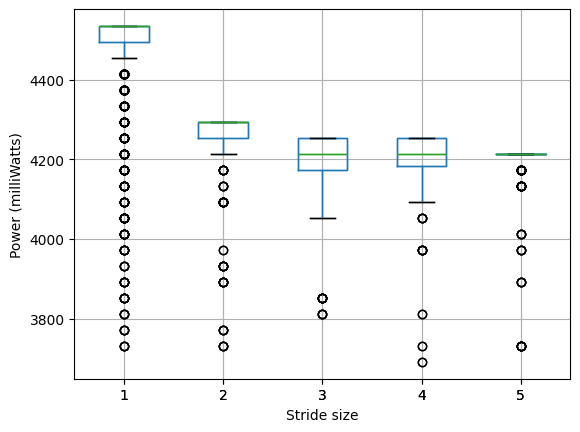

In [39]:
df = pd.concat(
    [
        metrics_df_k1["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k2["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k3["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k4["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k5["layer_power_including_idle_power_micro_watt"] * 1e-3,
    ],
    axis=1,
)


# set column names (will be displayed as plot labels)
df.columns = ['1', '2', '3', '4', '5']  

# use pandas' boxplot method
df.boxplot().set_ylabel('Power (milliWatts)')
df.boxplot().set_xlabel('Stride size')

Text(0.5, 0, 'Stride size')

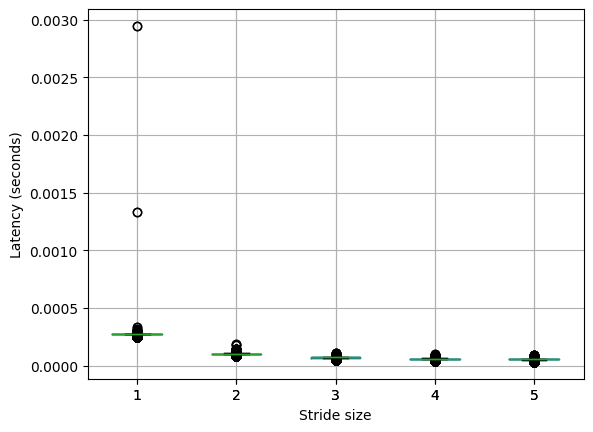

In [40]:
df = pd.concat(
    [
        metrics_df_k1["layer_run_time"] * 1e-3,
        metrics_df_k2["layer_run_time"] * 1e-3,
        metrics_df_k3["layer_run_time"] * 1e-3,
        metrics_df_k4["layer_run_time"] * 1e-3,
        metrics_df_k5["layer_run_time"] * 1e-3,
    ],
    axis=1,
)


# set column names (will be displayed as plot labels)
df.columns = ['1', '2', '3', '4', '5']  

# use pandas' boxplot method
df.boxplot().set_ylabel('Latency (seconds)')
df.boxplot().set_xlabel('Stride size')

Text(0.5, 0, 'Stride size')

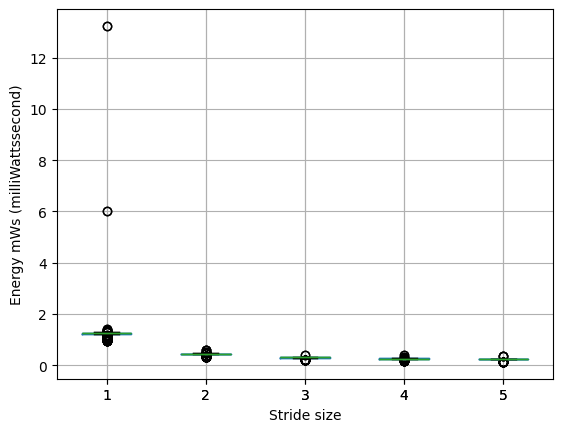

In [41]:
df = pd.concat(
    [   # microwatts converted to milliwatts * millseconds converted to seconds
        metrics_df_k1["layer_power_including_idle_power_micro_watt"] * 1e-3 * metrics_df_k1["layer_run_time"] * 1e-3,
        metrics_df_k2["layer_power_including_idle_power_micro_watt"] * 1e-3 * metrics_df_k2["layer_run_time"] * 1e-3,
        metrics_df_k3["layer_power_including_idle_power_micro_watt"] * 1e-3 * metrics_df_k3["layer_run_time"] * 1e-3,
        metrics_df_k4["layer_power_including_idle_power_micro_watt"] * 1e-3 * metrics_df_k4["layer_run_time"] * 1e-3,
        metrics_df_k5["layer_power_including_idle_power_micro_watt"] * 1e-3 * metrics_df_k5["layer_run_time"] * 1e-3,
    ],
    axis=1,
)


# set column names (will be displayed as plot labels)
df.columns = ['1', '2', '3', '4', '5']

# use pandas' boxplot method
df.boxplot().set_ylabel('Energy mWs (milliWattssecond)')
df.boxplot().set_xlabel('Stride size')